**Workflow**

1. Load MRI data, setup training, test, validation datasets
   * Create a dictionary containing images and masks from the dataset.
   * Split dataset into train, test and validation sets.
   * Perform id2label mapping (as done in Milestone 1)
   * Check if data and labels are getting correctly loaded.

2. Write a custom callback function that will:
   * Load images from the validation dataset during training.
   * Do model prediction after every epoch on the images.
   * Display image and prediction mask after every epoch to check training progress.

3. Write the training function for loading and training a Segformer model (you can use the SegFormer model from Hugging Face).
   * Set up training arguments for initializing training hyperparameters.
   * Load a pre-trained Segformer model checkpoint and train it.
   * Try different model checkpoints (at least 3) to see the impact on segmentation results.

4. Model inference and accuracy estimation
   * Do inference with trained model to identify tumor regions on a set of MR images.  
   * Compute and print mean IOU score between predictions and ground truths.

In [1]:
!nvidia-smi

Sat Mar  2 22:11:33 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   68C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
# Import necessary libraries for data manipulation, image processing, and visualization
import numpy as np
import pandas as pd
import os

from PIL import Image  # Python Imaging Library for image processing
from matplotlib import pyplot as plt  # Plotting library for visualizations
import glob  # File path matching using patterns
import cv2  # OpenCV library for computer vision tasks

import seaborn as sns  # Statistical data visualization library
from natsort import natsorted  # Natural sorting of filenames


In [3]:
## Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Specify the base path for the MRI dataset

exts = ('jpg', 'JPG', 'png', 'PNG',)
data_path = '/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/'

# Define image and label paths for the training set
image_path = os.path.join(data_path, 'images', 'train')
label_path = os.path.join(data_path, 'masks', 'train')

# Define image and label paths for the test set
test_path = os.path.join(data_path, 'images', 'test')
test_label_path = os.path.join(data_path, 'masks', 'test')


In [5]:
# List and sort image file paths for the training set
images = natsorted(
    [
        os.path.join(image_path, fname)
        for fname in os.listdir(image_path)
        if fname.endswith(exts) and not fname.startswith(".")
    ]
)

# List and sort mask file paths for the training set
masks = natsorted(
    [
        os.path.join(label_path, fname)
        for fname in os.listdir(label_path)
        if fname.endswith(exts) and not fname.startswith(".")
    ]
)

# List and sort image file paths for the test set
test_images = natsorted(
    [
        os.path.join(test_path, fname)
        for fname in os.listdir(test_path)
        if fname.endswith(exts) and not fname.startswith(".")
    ]
)

# List and sort mask file paths for the test set
test_labels = natsorted(
    [
        os.path.join(test_label_path, fname)
        for fname in os.listdir(test_label_path)
        if fname.endswith(exts) and not fname.startswith(".")
    ]
)


In [6]:
# Print the number of samples in the training set
print("Number of samples:", len(images), len(masks))

# Display file paths for the first 10 samples in the training set
for input_path, target_path in zip(images[:10], masks[:10]):
    print(input_path[-27:], "|", target_path[-28:])


Number of samples: 500 500
train/mri_mening_img000.png | train/mri_mening_mask000.png
train/mri_mening_img001.png | train/mri_mening_mask001.png
train/mri_mening_img002.png | train/mri_mening_mask002.png
train/mri_mening_img003.png | train/mri_mening_mask003.png
train/mri_mening_img004.png | train/mri_mening_mask004.png
train/mri_mening_img005.png | train/mri_mening_mask005.png
train/mri_mening_img006.png | train/mri_mening_mask006.png
train/mri_mening_img007.png | train/mri_mening_mask007.png
train/mri_mening_img008.png | train/mri_mening_mask008.png
train/mri_mening_img009.png | train/mri_mening_mask009.png


# Setup training, test, validation datasets

In [7]:
# Import the TensorFlow library
import tensorflow as tf

# List and set memory growth for available GPU devices
physical_devices = tf.config.list_physical_devices('GPU')

# Enable memory growth for each GPU device
[tf.config.experimental.set_memory_growth(pd, True) for pd in physical_devices]


[None]

In [8]:
# Set constants for image size and batch size
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Define a function to read image files
def read_files(image_path, mask=False):
    """
    Read image files from the specified path.

    Args:
        image_path (str): Path to the image file.
        mask (bool): Whether the image is a mask (True) or not (False).

    Returns:
        tf.Tensor: Processed image tensor.
    """
    # Read the contents of the image file
    image = tf.io.read_file(image_path)

    # Process the image based on whether it is a mask or not
    if mask:
        # Decode PNG and set shape for masks
        image = tf.image.decode_png(image, channels=1)
        image.set_shape([None, None, 1])
        # Resize and normalize masks
        image = tf.image.resize(images=image, size=[IMAGE_SIZE, IMAGE_SIZE])
        image = image / 255.
        image = tf.cast(image, tf.int32)  # Convert to integer type for masks
    else:
        # Decode PNG and set shape for non-masks (images)
        image = tf.image.decode_png(image, channels=3)
        image.set_shape([None, None, 3])
        # Resize and normalize images
        image = tf.image.resize(images=image, size=[IMAGE_SIZE, IMAGE_SIZE])
        image = image / 255.

    return image


In [9]:
# Define a function to load data from image and mask lists
def load_data(image_list, mask_list):
    """
    Load data from image and mask lists.

    Args:
        image_list (list): List of paths to image files.
        mask_list (list): List of paths to mask files.

    Returns:
        dict: Dictionary containing "pixel_values" (image tensor) and "labels" (mask tensor).
    """
    # Read and process image and mask files
    image = read_files(image_list)
    mask = read_files(mask_list, mask=True)

    # Transpose image dimensions for compatibility with the model
    image = tf.transpose(image, (2, 0, 1))

    # Squeeze the mask tensor to remove singleton dimensions
    mask = tf.squeeze(mask)

    return {"pixel_values": image, "labels": mask}

# Define a function to generate a TensorFlow dataset
def data_gen(image_list, mask_list, split='train'):
    """
    Generate a TensorFlow dataset.

    Args:
        image_list (list): List of paths to image files.
        mask_list (list): List of paths to mask files.
        split (str): Split identifier, e.g., 'train' or 'test'.

    Returns:
        tf.data.Dataset: TensorFlow dataset.
    """
    # Create a dataset from image and mask lists
    dataset = tf.data.Dataset.from_tensor_slices((image_list, mask_list))

    # Shuffle the dataset for training split
    dataset = dataset.shuffle(10 * BATCH_SIZE) if split == 'train' else dataset

    # Map the load_data function to the dataset elements
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch the dataset with a specified batch size
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)

    # Prefetch elements to improve data loading performance
    return dataset.prefetch(tf.data.AUTOTUNE)



#  Create id2label mapping
* See step 2 of Milestone 1

In [10]:
id2label = {
    0:  'bg',
    1:  'tumor',

}
label2id = { label: id for id, label in id2label.items() }
n_classes = len(id2label)
n_classes

2

In [11]:

# Generate TensorFlow datasets for training, validation, and testing
train_ds = data_gen(images[:300], masks[:300])

# For validation dataset, use the last 100 samples
val_ds = data_gen(images[-100:], masks[-100:], split='validation')

# Generate a test dataset with the first 200 samples
test_ds = data_gen(test_images[0:200], test_labels[0:200])


# Check if data is getting loaded correctly in the generator

0.9216888 0.0 1 0


Text(0.5, 1.0, 'Mask')

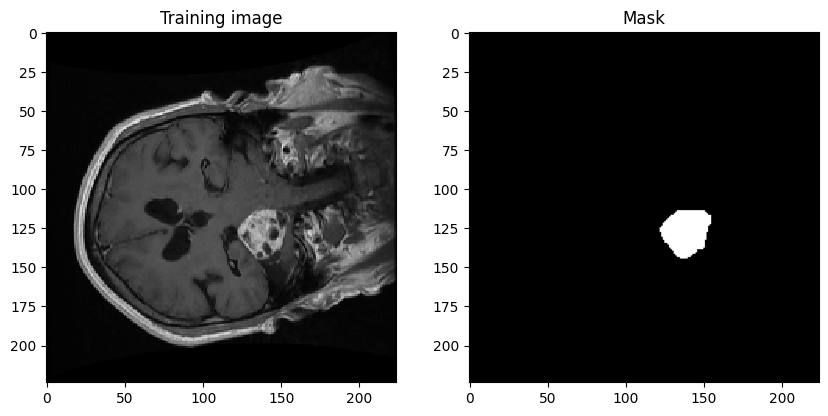

In [12]:
# Create a DataFrame from the first batch of the training dataset for inspection
check_data = pd.DataFrame(train_ds, columns=['pixel_values', 'labels'])

# Extract an example image and mask for inspection
im = check_data['pixel_values'][0][0]  # Check image
mask = check_data['labels'][0][0]  # Check mask

# Convert TensorFlow tensors to NumPy arrays
npimg = im.numpy()
npmask = mask.numpy()

# Print the maximum and minimum values of image and mask to check their value ranges
print(npimg.max(), npimg.min(), npmask.max(), npmask.min())

# Create a figure for visualization
fig = plt.figure(figsize=(10, 10))

# Add subplots for image and mask visualization
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)

# Display the image in the first subplot
ax1.imshow(np.transpose(npimg, (1, 2, 0)), interpolation='nearest')
ax1.set_title('Training image')

# Display the mask in the second subplot
ax2.imshow(npmask, cmap='gray')
ax2.set_title('Mask')


# Load Huggingface Segmentation transformer Model

In [ ]:
!pip install transformers==4.31.0

In [15]:
import keras
from transformers import TFSegformerForSemanticSegmentation


#Models to try :
# nvidia/mit-b0
# nvidia/segformer-b0-finetuned-ade-512-512
# nvidia/segformer-b1-finetuned-ade-512-512
# nvidia/segformer-b3-finetuned-ade-512-512
# nvidia/segformer-b4-finetuned-ade-512-512

# Define the model checkpoint to use for semantic segmentation
# Choose from the provided models or specify a custom one
model_checkpoint = "nvidia/segformer-b0-finetuned-ade-512-512"

# Set the number of labels for semantic segmentation
num_labels = n_classes  # Assuming n_classes is previously defined

# Load the Segformer model for semantic segmentation
model = TFSegformerForSemanticSegmentation.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,  # Mapping from label indices to label names
    label2id=label2id,  # Mapping from label names to label indices
    ignore_mismatched_sizes=True,  # Ignore mismatched sizes during training
)

# Set hyperparameters for training
batch_size = 2
num_epochs = 60
num_train_steps = 10
learning_rate = 6e-5
weight_decay_rate = 0.01

# Compile the model

opt = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer='adam')


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSegformerForSemanticSegmentation: ['decode_head.classifier.weight', 'decode_head.classifier.bias', 'decode_head.batch_norm.num_batches_tracked']
- This IS expected if you are initializing TFSegformerForSemanticSegmentation from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSegformerForSemanticSegmentation from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSegformerForSemanticSegmentation were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSegformerForSemanticSegmentation for predictions without further training.
Some w

* ## Custom callback function to do model prediction after every epoch on the images.
* ## Display image, prediction mask and segmentation accuracy after every epoch to check training progress.

In [16]:
# Import necessary libraries for visualization and callbacks
from IPython.display import clear_output
from random import randrange

# Define a function to create a mask from predicted probabilities
def create_mask(pred_mask):
    pred_mask = tf.math.argmax(pred_mask, axis=1)
    pred_mask = tf.expand_dims(pred_mask, -1)
    return pred_mask[0]

# Define a function to calculate the mean Intersection over Union (IoU)
def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

def calculate_mean_iou(y_true, y_pred):
    class_iou = []
    for i in range(1, np.max(y_true) + 1):
        y_true_i = (y_true == i)
        y_pred_i = (y_pred == i)
        class_iou.append(calculate_iou(y_true_i, y_pred_i))
    mean_iou = np.mean(class_iou)
    return mean_iou

# Define a function to show predictions and evaluation metrics
def show_predictions(dataset=None, num=1):
    if dataset:
        for sample in dataset.take(num):
            # Extract images and masks from the sample
            images, masks = sample["pixel_values"], sample["labels"]
            masks = tf.expand_dims(masks, -1)

            # Make predictions using the trained model
            pred_masks = model.predict(images).logits
            images = tf.transpose(images, (0, 2, 3, 1))

            # Create binary masks
            pred_m = create_mask(pred_masks)

            # Convert masks to NumPy arrays
            mask_ar = np.array(masks[0]).astype('float32')

            pred_m = np.array(pred_m).astype('float32')
            # print (mask_ar.shape, pred_m.shape )

            # Resize masks to the same dimensions
            mask_ar = cv2.resize(mask_ar, dsize=(pred_m.shape[0], pred_m.shape[1]), interpolation=cv2.INTER_CUBIC)
            pred_ar = cv2.resize(pred_m, dsize=(pred_m.shape[0], pred_m.shape[1]), interpolation=cv2.INTER_CUBIC)

            mask_ar = np.round(mask_ar).astype(int)
            pred_ar = np.round(pred_ar).astype(int)
            # Print mask shapes and mean IoU score
            # print(mask_ar.shape, pred_ar.shape)

            print("mean IOU score", calculate_mean_iou(pred_ar, mask_ar))

            # Display images, predicted masks, and ground truth masks
            plt.figure(figsize=(12, 12))
            plt.subplot(1, 3, 1)
            plt.axis('off')
            plt.imshow(images[0])
            plt.title('Image')
            plt.subplot(1, 3, 2)
            plt.axis('off')
            plt.imshow(pred_m)
            plt.title("Pred")
            plt.subplot(1, 3, 3)
            plt.axis('off')
            plt.imshow(masks[0])
            plt.title("Ground truth")

            plt.show()

# Define a custom callback for displaying predictions during training
class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, **kwargs):
        super().__init__(**kwargs)
        self.dataset = dataset

    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        show_predictions(self.dataset)
        print("\nSample Prediction after epoch {}\n".format(epoch + 1))


1/1 [==============================] - 0s 55ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.9285714285714286


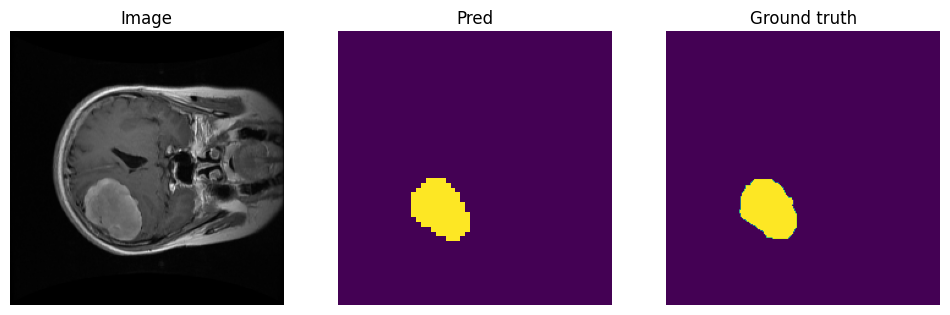


Sample Prediction after epoch 60

10/10 [==============================] - 7s 668ms/step - loss: 0.0031 - val_loss: 0.0084


In [17]:
## Set for training
callbacks=[DisplayCallback(val_ds)]
model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=callbacks,
    steps_per_epoch = 10,
    epochs= num_epochs
)

#Upload model to hub

In [ ]:
from huggingface_hub import login
login(token='Your token')  # The login token should be kept private and refreshed periodically through your Huggingface account.
model.push_to_hub("Segformer-MRIseg_model_Mar24")

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


tf_model.h5:   0%|          | 0.00/15.1M [00:00<?, ?B/s]

# Do inference and display results on a set of test images, print segmentation accuracy

1/1 [==============================] - 0s 43ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.8387096774193549


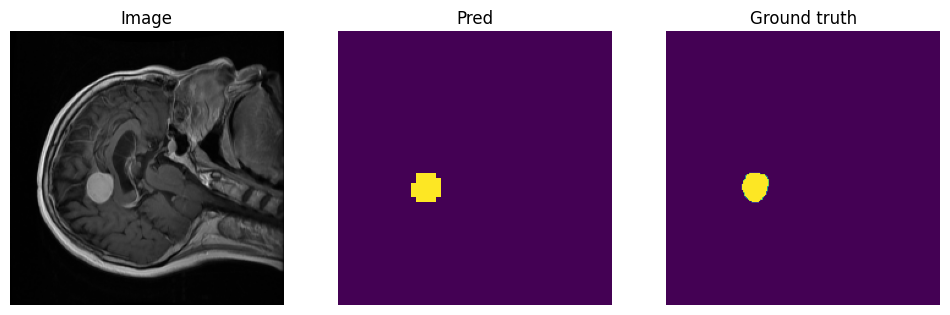

1/1 [==============================] - 0s 39ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.47619047619047616


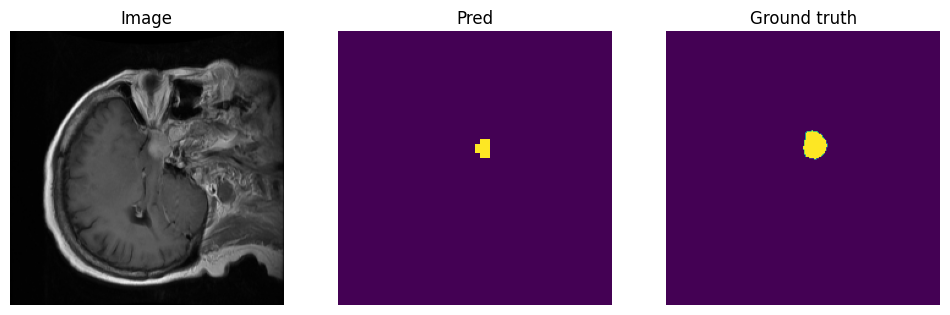

1/1 [==============================] - 0s 43ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.9411764705882353


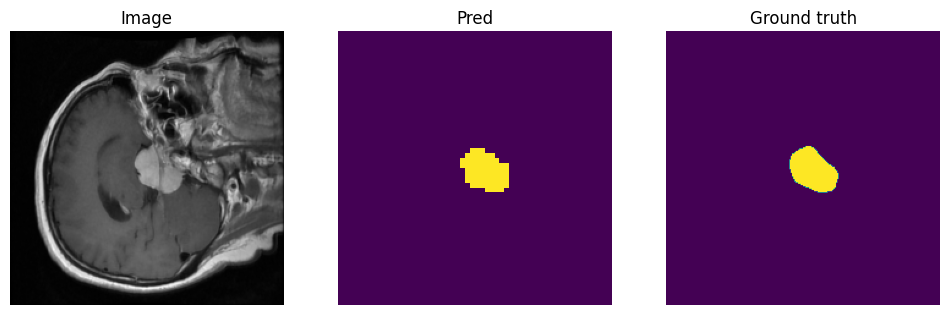

1/1 [==============================] - 0s 39ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.6956521739130435


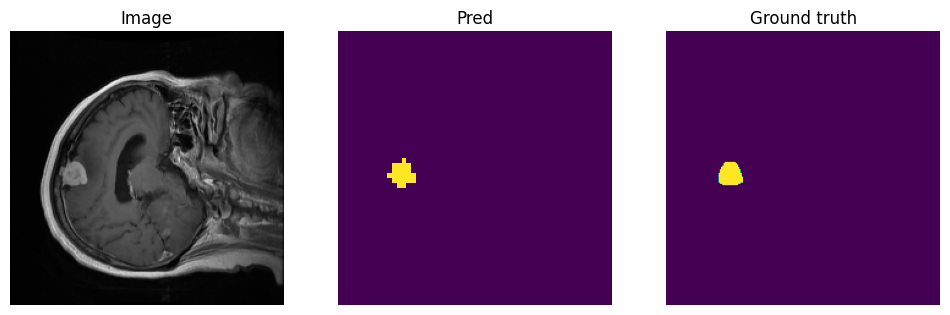

1/1 [==============================] - 0s 51ms/step
(224, 224, 1) (56, 56, 1)
(56, 56) (56, 56)
mean IOU score 0.8


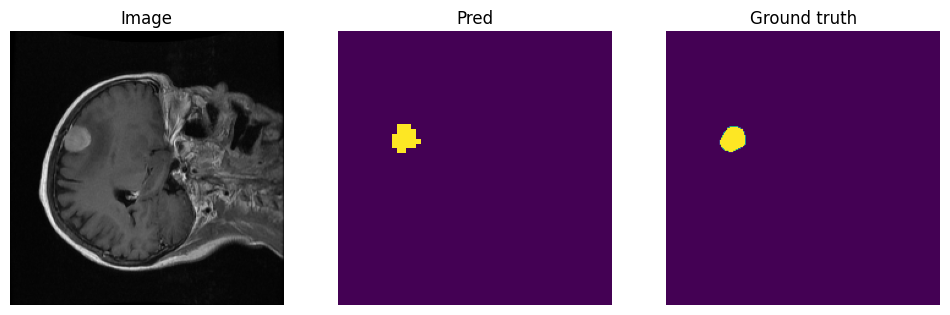

In [18]:
show_predictions(test_ds, 5)